# End-to-End Test

## Import Functions to Test

In [1]:
from raag_midi_gen.tokenization.decoding import decode_output
from raag_midi_gen.tokenization.encoding import encode_target

## Import Helper Functions

In [2]:
import random

import muspy

from raag_midi_gen.datasets import midi_files_dataset
from raag_midi_gen.utils.midi_utils import play_muspy_music

In [3]:
# test_clip_filename = 'Taraana - Antra 2.0.mid'        # EASY
test_clip_filename = 'Aeri Aali - Sthaayi 1.1_2.mid'  # HARD

## Get Data Sample

In [4]:
dataset = midi_files_dataset.get_dataset()
midi_filename, original_midi = dataset[test_clip_filename]

Chosen File: Aeri Aali - Sthaayi 1.1_2.mid
------------------


[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

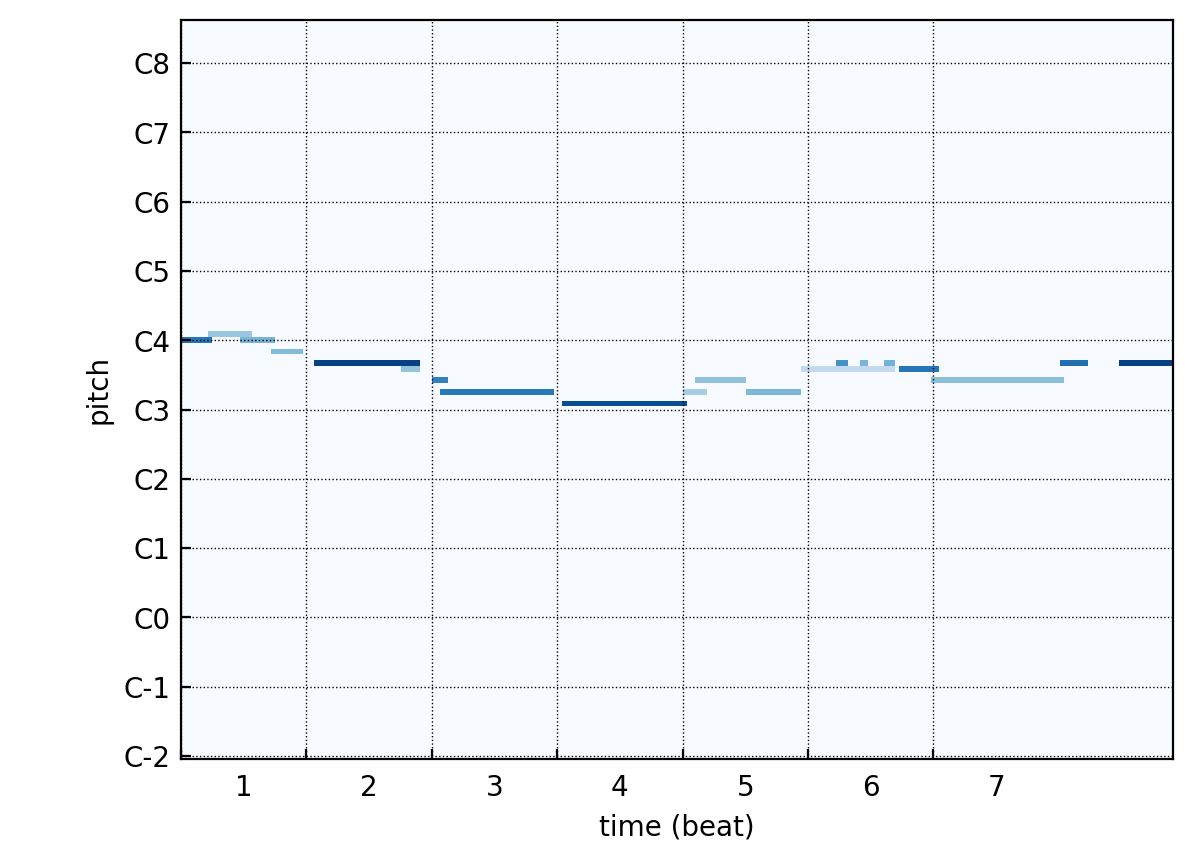

In [5]:
print(f'Chosen File: {midi_filename}')
print('------------------')
muspy.show_pianoroll(original_midi)

## Encode Target

In [6]:
target_encoding = encode_target(original_midi)
pitches = target_encoding['pitch']
octaves = target_encoding['octave']
velocities = target_encoding['velocity']
event_types = target_encoding['event_type']

## Decode

In [7]:
decoded_midi = decode_output(velocities, pitches, octaves, event_types)

## Test Similarity of Decoded and Original

In [8]:
print(f'{midi_filename}: ORIGINAL')
print('------------------')
play_muspy_music(original_midi)

print(f'{midi_filename}: DECODED')
print('------------------')
play_muspy_music(decoded_midi)

Aeri Aali - Sthaayi 1.1_2.mid: ORIGINAL
------------------
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'tmp.wav'..


Aeri Aali - Sthaayi 1.1_2.mid: DECODED
------------------
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'tmp.wav'..


# Inspect Original

In [10]:
original_midi.tracks[0].notes

[Note(time=0, pitch=72, duration=24, velocity=93),
 Note(time=21, pitch=73, duration=33, velocity=49),
 Note(time=45, pitch=72, duration=27, velocity=60),
 Note(time=69, pitch=70, duration=24, velocity=56),
 Note(time=102, pitch=68, duration=81, velocity=119),
 Note(time=168, pitch=67, duration=15, velocity=51),
 Note(time=192, pitch=65, duration=12, velocity=87),
 Note(time=198, pitch=63, duration=87, velocity=91),
 Note(time=291, pitch=61, duration=96, velocity=113),
 Note(time=384, pitch=63, duration=18, velocity=44),
 Note(time=393, pitch=65, duration=39, velocity=52),
 Note(time=432, pitch=63, duration=42, velocity=58),
 Note(time=474, pitch=67, duration=72, velocity=33),
 Note(time=501, pitch=68, duration=9, velocity=78),
 Note(time=519, pitch=68, duration=6, velocity=59),
 Note(time=537, pitch=68, duration=9, velocity=61),
 Note(time=549, pitch=67, duration=30, velocity=93),
 Note(time=573, pitch=65, duration=102, velocity=54),
 Note(time=672, pitch=68, duration=21, velocity=96)

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

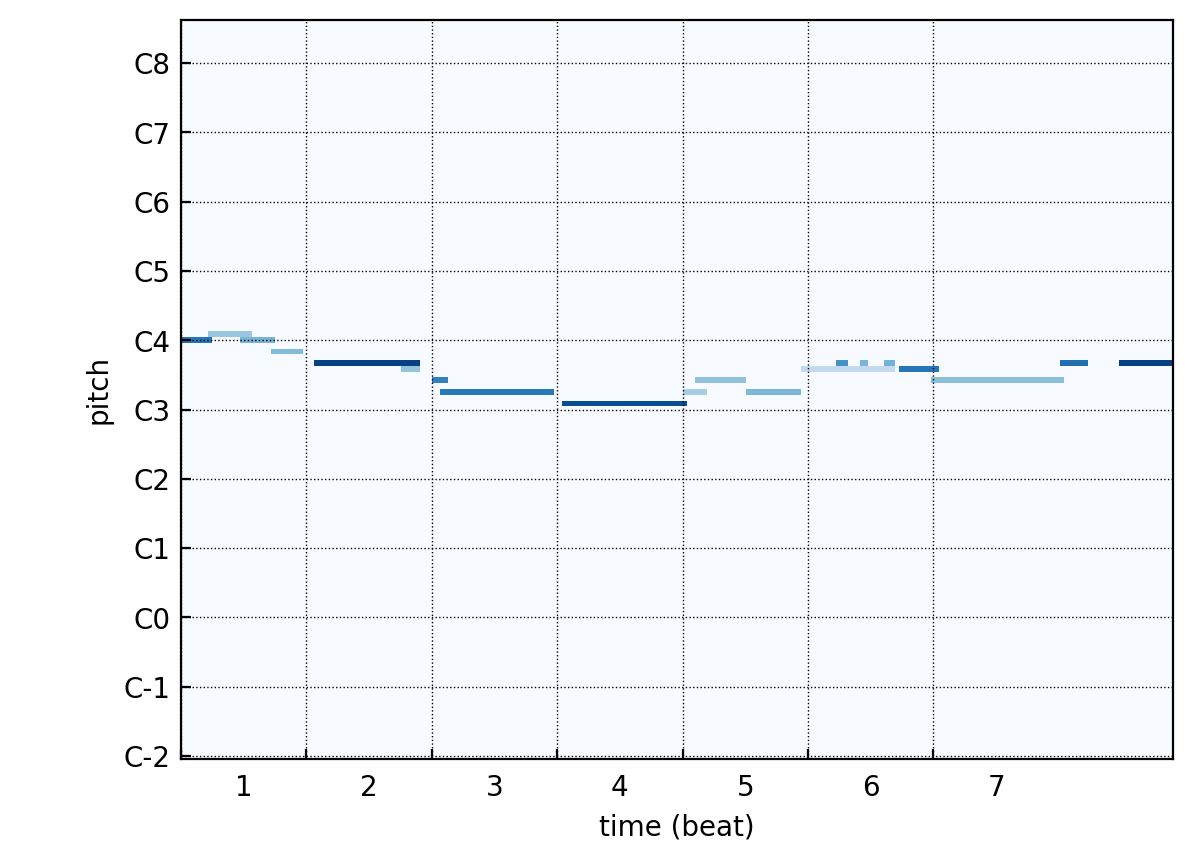

In [11]:
muspy.show_pianoroll(original_midi)

# Inspect Decoded

In [12]:
decoded_midi.tracks[0].notes

[Note(time=0, pitch=72, duration=24, velocity=93),
 Note(time=21, pitch=73, duration=33, velocity=49),
 Note(time=45, pitch=72, duration=27, velocity=60),
 Note(time=69, pitch=70, duration=24, velocity=56),
 Note(time=102, pitch=68, duration=81, velocity=119),
 Note(time=168, pitch=67, duration=16, velocity=51),
 Note(time=192, pitch=65, duration=12, velocity=87),
 Note(time=198, pitch=63, duration=87, velocity=91),
 Note(time=291, pitch=61, duration=96, velocity=113),
 Note(time=384, pitch=63, duration=18, velocity=44),
 Note(time=393, pitch=65, duration=39, velocity=52),
 Note(time=433, pitch=63, duration=41, velocity=58),
 Note(time=501, pitch=68, duration=9, velocity=78),
 Note(time=519, pitch=68, duration=6, velocity=59),
 Note(time=475, pitch=67, duration=71, velocity=33),
 Note(time=537, pitch=68, duration=10, velocity=61),
 Note(time=549, pitch=67, duration=30, velocity=93),
 Note(time=573, pitch=65, duration=102, velocity=54),
 Note(time=672, pitch=68, duration=21, velocity=96

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

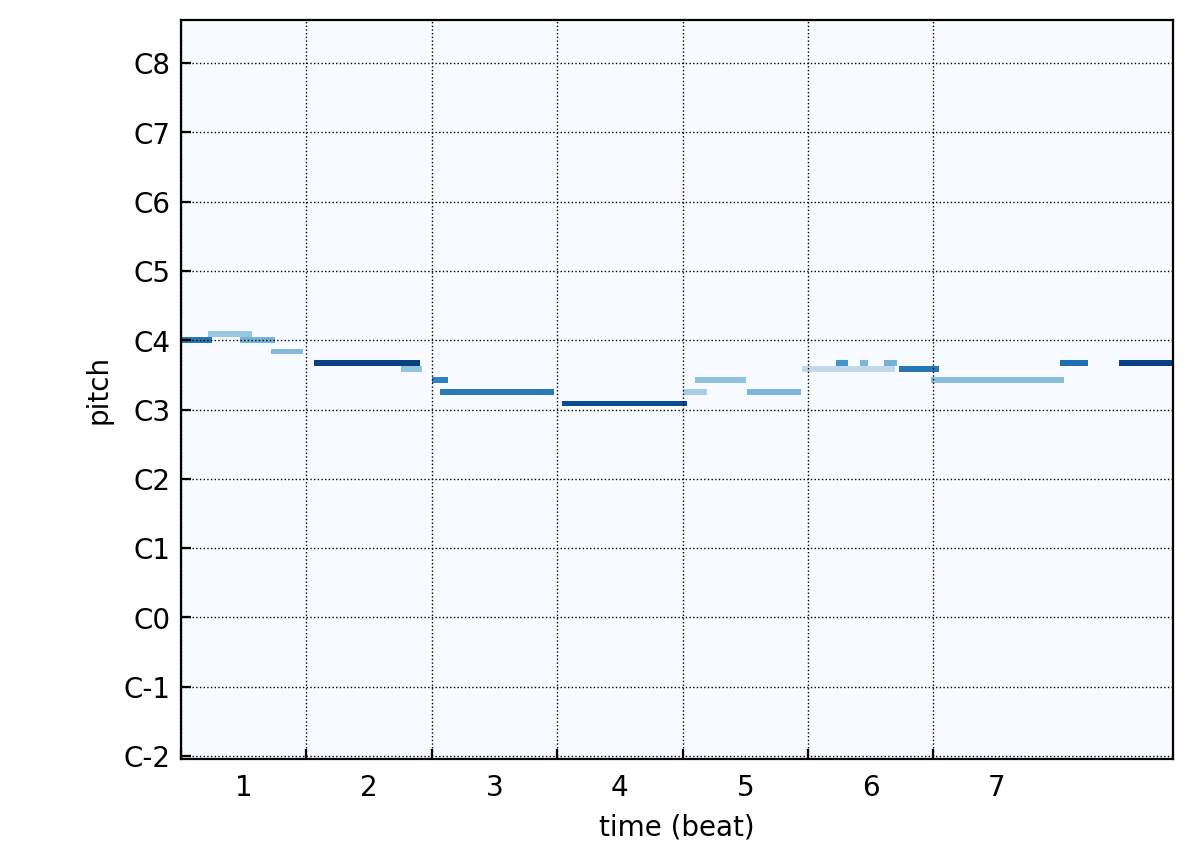

In [13]:
muspy.show_pianoroll(decoded_midi)

# Working Out `torch.argmax` Behaviour

In [134]:
import torch

from raag_midi_gen.tokenization.vocab import (
    NOTE_VOCAB_DECODABLE_TOKENS_START, NOTE_VOCAB_DECODABLE_TOKENS_END,
    OCTAVE_VOCAB_DECODABLE_TOKENS_START, OCTAVE_VOCAB_DECODABLE_TOKENS_END,
)

In [135]:
print(pitches.shape)
print(pitches[..., NOTE_VOCAB_DECODABLE_TOKENS_START:NOTE_VOCAB_DECODABLE_TOKENS_END].shape)

torch.Size([768, 14])
torch.Size([768, 12])


In [127]:
print(pitches)

tensor(1)


In [136]:
with torch.no_grad():
    pitches = torch.argmax(pitches[..., NOTE_VOCAB_DECODABLE_TOKENS_START:NOTE_VOCAB_DECODABLE_TOKENS_END], dim=-1)
    pitches += NOTE_VOCAB_DECODABLE_TOKENS_START
    print('PITCHES')
    print('--------------------')
    print(pitches.shape)
    print(pitches)
    print()
    
    octaves = torch.argmax(octaves[..., OCTAVE_VOCAB_DECODABLE_TOKENS_START:OCTAVE_VOCAB_DECODABLE_TOKENS_END], dim=-1)
    octaves += OCTAVE_VOCAB_DECODABLE_TOKENS_START
    print('OCTAVES')
    print('--------------------')
    print(octaves.shape)
    print(octaves)
    print()
    
    midi_pitches = octaves*12 + pitches
    print('MIDI PITCHES')
    print('--------------------')
    print(midi_pitches.shape)
    print(midi_pitches)
    print()

PITCHES
--------------------
torch.Size([768])
tensor([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  